In [7]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.impute import SimpleImputer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, roc_auc_score, precision_score, recall_score, f1_score

# 1. Load Data
df = pd.read_csv("loan_prediction.csv")
df = df.drop(columns=['Loan_ID'])  # Drop identifier

# 2. Target Preparation
# Map Y/N to 1/0 (1 = Approved, 0 = Rejected)
df['Loan_Status'] = df['Loan_Status'].map({'Y': 1, 'N': 0})
X = df.drop(columns=['Loan_Status'])
y = df['Loan_Status']

# 3. Define Column Types
cat_cols = ['Gender', 'Married', 'Dependents', 'Education', 'Self_Employed', 'Property_Area', 'Credit_History']
num_cols = ['ApplicantIncome', 'CoapplicantIncome', 'LoanAmount', 'Loan_Amount_Term']

# 4. Preprocessing Pipelines
# Numerical: Median imputation -> Standard Scaling
num_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='median')),
    ('scaler', StandardScaler())
])

# Categorical: Mode imputation -> One-Hot Encoding
cat_transformer = Pipeline(steps=[
    ('imputer', SimpleImputer(strategy='most_frequent')),
    ('onehot', OneHotEncoder(handle_unknown='ignore', drop='first'))
])

preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, num_cols),
        ('cat', cat_transformer, cat_cols)
    ])

# 5. Train-Test Split (Stratified to maintain class proportions)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# 6. Initialize Models
# Using class_weight='balanced' to handle the target imbalance (More Y's than N's)
models = {
    'Logistic Regression': LogisticRegression(random_state=42, max_iter=1000, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(random_state=42, n_estimators=100, max_depth=5, class_weight='balanced')
}

# 7. Train and Evaluate
results = {}
for name, model in models.items():
    clf = Pipeline(steps=[('preprocessor', preprocessor),
                          ('classifier', model)])

    clf.fit(X_train, y_train)
    y_pred = clf.predict(X_test)
    y_proba = clf.predict_proba(X_test)[:, 1]

    # Store metrics focused on the positive class (Approved)
    results[name] = {
        'Precision': round(precision_score(y_test, y_pred), 3),
        'Recall': round(recall_score(y_test, y_pred), 3),
        'F1-Score': round(f1_score(y_test, y_pred), 3),
        'ROC-AUC': round(roc_auc_score(y_test, y_proba), 3)
    }

# Display Results
print(pd.DataFrame(results).T)

                     Precision  Recall  F1-Score  ROC-AUC
Logistic Regression      0.872   0.882     0.877    0.854
Random Forest            0.837   0.906     0.870    0.806


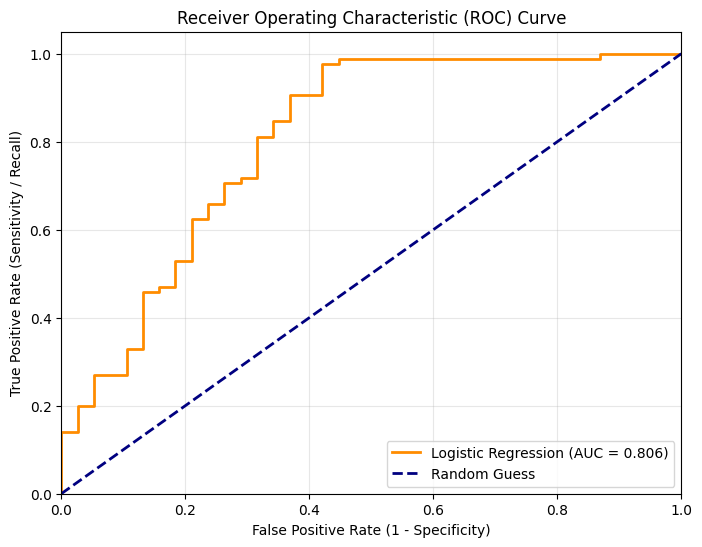

In [8]:
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc

# 1. Get predicted probabilities for the Logistic Regression model
# (Assuming 'clf' is currently your trained Logistic Regression pipeline)
y_proba_lr = clf.predict_proba(X_test)[:, 1]

# 2. Calculate FPR, TPR, and the Area Under the Curve (AUC)
fpr, tpr, thresholds = roc_curve(y_test, y_proba_lr)
roc_auc = auc(fpr, tpr)

# 3. Plot the ROC Curve
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='darkorange', lw=2, label=f'Logistic Regression (AUC = {roc_auc:.3f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--', label='Random Guess')

# Formatting the plot
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate (1 - Specificity)')
plt.ylabel('True Positive Rate (Sensitivity / Recall)')
plt.title('Receiver Operating Characteristic (ROC) Curve')
plt.legend(loc="lower right")
plt.grid(alpha=0.3)

# Display the chart (You can right-click and save this image for your document)
plt.show()